# 🧹 บทที่ 03 — Gate Filter & Masking: จากพื้นฐานสู่การกรอง Noise/Clutter หลายเงื่อนไข
### หลักสูตรแลปเรดาร์ตรวจอากาศด้วย Py-ART และ wradlib

**ระดับ:** ขั้นกลาง  |  **ต้องมีก่อน:** รันบทที่ 00 แล้ว

บทนี้พานิสิตเข้าใจการควบคุมคุณภาพข้อมูล (QC) แบบ **ต่อเนื่องเป็นขั้น**: เริ่มจากรู้จัก `GateFilter` เงื่อนไขเดียว → เข้าใจและ**ทดสอบความไวของ SNR ต่อค่า TOA** → รวมหลายเงื่อนไข (SNR + texture-based) เพื่อ**กรอง noise และ clutter** → สร้างฟิลด์ `filtered_reflectivity` พร้อมใช้งานต่อ

**เส้นเรื่องของบท (ร้อยเรียง):**

*ตอนที่ 1 — เข้าใจ GateFilter เงื่อนไขเดียว*
| A1 | สำรวจ RHOHV + ฮิสโตแกรม 2 มิติ (ลายเซ็น clutter) |
| A2 | กรอง clutter ด้วย RHOHV (`exclude_below`) |
| A3 | ทัวร์เมธอด: `exclude_below/outside/invalid/masked` |

*ตอนที่ 2 — SNR และการทดสอบ TOA*
| A4 | SNR และ TOA คืออะไร |
| A5 | **ทดสอบ sensitivity ของ TOA** (เหตุผลที่ SNR อาจว่างเปล่า) |
| A6 | เลือก TOA ที่เหมาะ → เทียบ SNR กับ reflectivity |

*ตอนที่ 3 — กรอง noise/clutter หลายเงื่อนไข*
| A7 | `moment_and_texture_based_gate_filter` + SNR → `filtered_reflectivity` |
| A8 | รวมหลายเงื่อนไข + ตาราง % + ค่าที่เก็บ vs ตัดออก |
| A9 | กรอง Doppler velocity + trade-off เกณฑ์ RHOHV |

*ตอนที่ 4 — ประยุกต์*
| A10 | ผลของการกรองต่อ CAPPI / QPE |

---


## 🧠 หลักการเบื้องต้น: สัญญาณผิดและ "ลายเซ็น"

ข้อมูลเรดาร์ดิบปนสัญญาณที่ไม่ใช่ฝนจริง แต่ละชนิดมีลายเซ็นต่างกัน:

| แหล่งสัญญาณผิด | ลายเซ็น | เกณฑ์กรอง |
|---|---|---|
| **Ground clutter** (ภูเขา/อาคาร) | RHOHV ต่ำ, velocity ~0, ใกล้สถานี | RHOHV < 0.8, texture |
| **สัญญาณรบกวน (noise)** | **SNR ต่ำ**, dBZ ต่ำ | **SNR** |
| **สิ่งแปลกปลอม/ชีวภาพ** | RHOHV ต่ำ, texture สูง | RHOHV, texture |
| **ค่าผิดปกติเชิงกายภาพ** | นอกช่วงที่เป็นไปได้ | `exclude_outside` |

**`GateFilter`** สร้างเงื่อนไข "ตัดทิ้ง" ระดับ gate: `exclude_below/above`, `exclude_outside/inside`, `exclude_invalid/masked`, และ `include_*` (เก็บเฉพาะ) เมื่อพลอต/คำนวณต่อ ส่ง `gatefilter=` เข้าไป


## ⚙️ ส่วนหัวมาตรฐาน (ติดตั้งไลบรารี + เชื่อม Drive + ฟอนต์ไทย)


In [ ]:
%pip install -q arm_pyart

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.8/157.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 66.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sou

In [ ]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyart
import warnings; warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')
ROOT = '/content/drive/MyDrive/tmd_radar_course'
sys.path.append(os.path.join(ROOT, '9config'))
import course_paths as P
assert os.path.exists(P.RADAR_1000), "⚠️ ไม่พบข้อมูลเรดาร์ — กรุณารัน Notebook 00 ก่อน"
OUT = P.results_dir('lesson03')
print("พร้อมแล้ว ✅  ผลลัพธ์บันทึกที่:", OUT)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119

Mounted at /content/drive
พร้อมแล้ว ✅  ผลลัพธ์บันทึกที่: /content/drive/MyDrive/tmd_radar_course/1results/lesson03


### 🔤 ติดตั้งฟอนต์ไทยสำหรับกราฟ (จำเป็น — มิฉะนั้นข้อความไทยจะแสดงเป็นกล่อง □□□)

ดาวน์โหลดฟอนต์ **Sarabun** (ฟอนต์ราชการไทย เหมาะงานตีพิมพ์) มาลงทะเบียนกับ matplotlib พร้อมตั้งสไตล์กราฟระดับตีพิมพ์ — รันเซลล์นี้ก่อนพลอตทุกครั้ง

In [ ]:
# ── ติดตั้ง & ตั้งค่าฟอนต์ไทยให้ matplotlib (ต้องรันก่อนพลอตกราฟที่มีข้อความไทย) ──
import os, glob, subprocess, urllib.request
import matplotlib as mpl, matplotlib.pyplot as plt, matplotlib.font_manager as fm

def setup_thai_font(verbose=True):
    d = '/usr/share/fonts/truetype/sarabun'; os.makedirs(d, exist_ok=True)
    # 1) Sarabun จาก Google Fonts (ฟอนต์ราชการไทย)
    if not glob.glob(d + '/*.ttf'):
        base = 'https://github.com/google/fonts/raw/main/ofl/sarabun/'
        for fn in ('Sarabun-Regular.ttf', 'Sarabun-Bold.ttf'):
            try: urllib.request.urlretrieve(base + fn, os.path.join(d, fn))
            except Exception: pass
    # 2) สำรอง: ฟอนต์ไทย TLWG ผ่าน apt (มีใน Colab เสมอ)
    if not glob.glob(d + '/*.ttf') and not glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf'):
        subprocess.run(['apt-get', '-qq', '-y', 'install', 'fonts-thai-tlwg'], capture_output=True)
    # ลงทะเบียนฟอนต์ที่ติดตั้ง
    for fp in glob.glob(d + '/*.ttf') + glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf'):
        try: fm.fontManager.addfont(fp)
        except Exception: pass
    avail = {f.name for f in fm.fontManager.ttflist}
    chosen = next((n for n in ('Sarabun','Loma','Garuda','Norasi') if n in avail), None)
    if chosen: mpl.rcParams['font.family'] = chosen
    mpl.rcParams['axes.unicode_minus'] = False
    if verbose:
        print('ฟอนต์ไทยที่ใช้:', chosen or 'ไม่พบ — ลองรันเซลล์นี้อีกครั้งหลังติดตั้ง')
    return chosen

setup_thai_font()
# สไตล์กราฟระดับตีพิมพ์ (ฟอนต์ใหญ่ อ่านง่าย)
plt.rcParams.update({'figure.dpi':120, 'savefig.dpi':300, 'font.size':13,
    'axes.titlesize':16, 'axes.labelsize':14, 'xtick.labelsize':12,
    'ytick.labelsize':12, 'legend.fontsize':13, 'axes.unicode_minus':False})

ฟอนต์ไทยที่ใช้: Sarabun


In [ ]:
radar = pyart.io.read(P.RADAR_1000)
try:
    nyq = float(radar.instrument_parameters['nyquist_velocity']['data'][0])
except Exception:
    nyq = 30.0

def ppi(ax, field, sweep=0, vmin=None, vmax=None, cmap='NWSRef', gf=None, title=None, label=''):
    "helper พลอต PPI แบบพิกัดกิโลเมตร"
    d = pyart.graph.RadarDisplay(radar)
    d.plot(field, sweep=sweep, ax=ax, vmin=vmin, vmax=vmax, cmap=cmap, gatefilter=gf,
           colorbar_label=label, title=title or field)
    ax.set_xlim(-240,240); ax.set_ylim(-240,240); ax.set_aspect('equal')
    ax.set_xlabel('กม.'); ax.set_ylabel('กม.')

print("ฟิลด์ในไฟล์:", list(radar.fields.keys()))
print("Nyquist =", round(nyq,2), "m/s")

ฟิลด์ในไฟล์: ['reflectivity', 'velocity', 'spectrum_width', 'corrected_reflectivity', 'corrected_differential_reflectivity', 'differential_phase', 'cross_correlation_ratio']
Nyquist = 8.38 m/s


---
# ตอนที่ 1 — เข้าใจ GateFilter เงื่อนไขเดียว

## A1 — สำรวจ RHOHV และระบุ clutter ด้วยฮิสโตแกรม 2 มิติ

ก่อนตั้งเกณฑ์ต้อง "รู้จักข้อมูล" — RHOHV ใกล้ 1 = ฝนจริง, ต่ำ = clutter/สิ่งแปลกปลอม


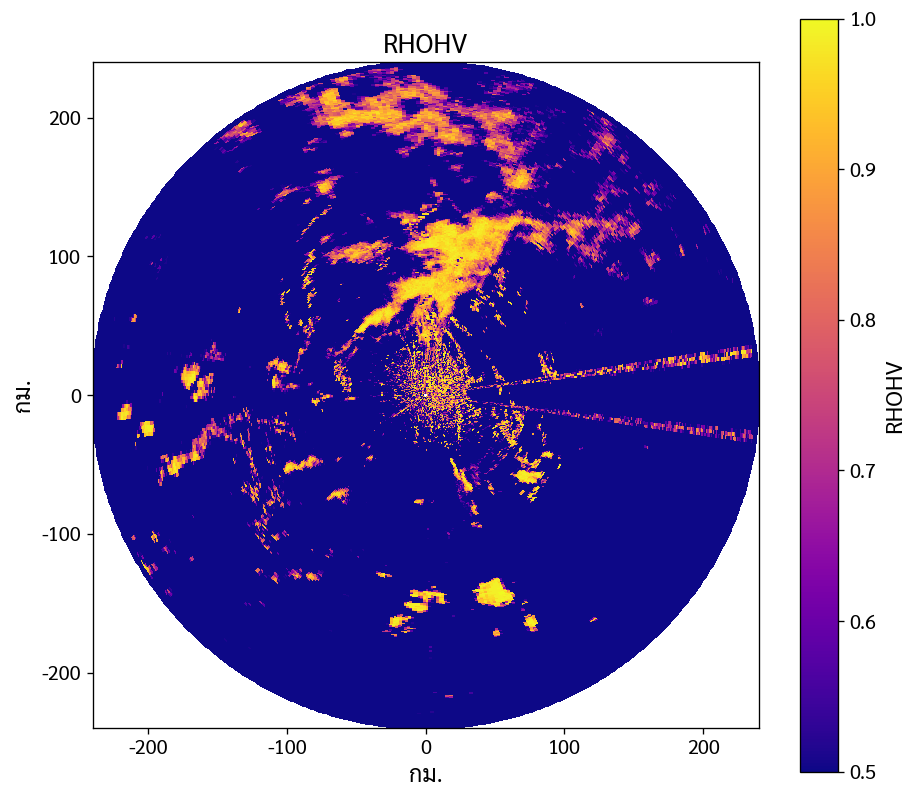

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
ppi(ax, 'cross_correlation_ratio', vmin=0.5, vmax=1.0, cmap='plasma', title='RHOHV', label='RHOHV')
plt.tight_layout(); plt.show()

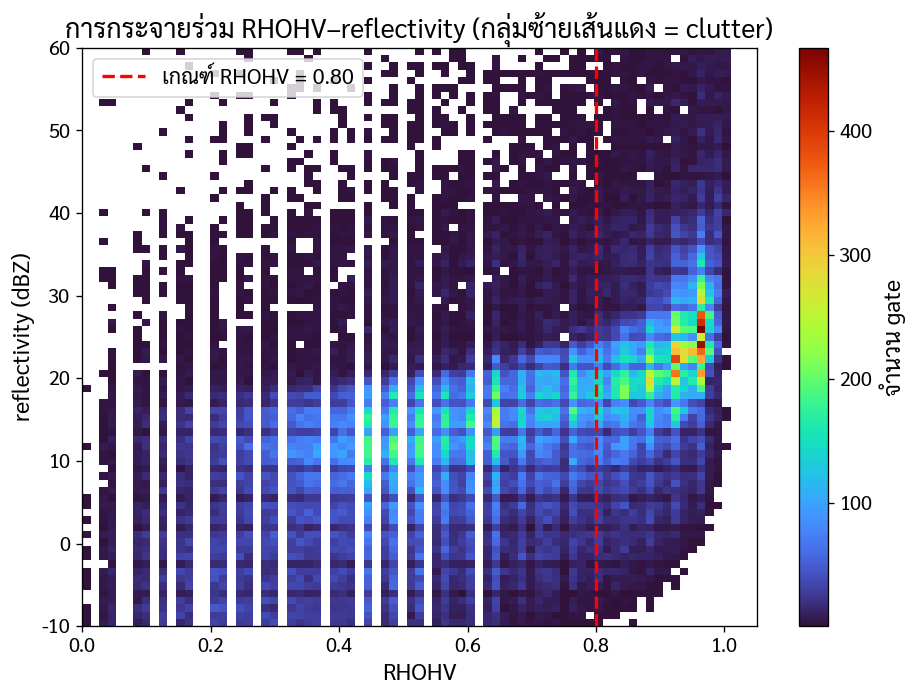

In [ ]:
rho = np.ma.filled(radar.fields['cross_correlation_ratio']['data'], np.nan).ravel()
ref = np.ma.filled(radar.fields['reflectivity']['data'], np.nan).ravel()
ok = np.isfinite(rho) & np.isfinite(ref)
fig, ax = plt.subplots(figsize=(8, 6))
h = ax.hist2d(rho[ok], ref[ok], bins=[np.linspace(0,1.05,80), np.linspace(-10,60,80)], cmap='turbo', cmin=1)
ax.axvline(0.80, color='red', ls='--', lw=2, label='เกณฑ์ RHOHV = 0.80')
ax.set_xlabel('RHOHV'); ax.set_ylabel('reflectivity (dBZ)')
ax.set_title('การกระจายร่วม RHOHV–reflectivity (กลุ่มซ้ายเส้นแดง = clutter)')
ax.legend(); plt.colorbar(h[3], ax=ax, label='จำนวน gate')
plt.tight_layout(); plt.show()

**การแปลผล:** ฝนจริงกระจุกที่ RHOHV สูง (~0.95–1.0) ส่วนกลุ่ม RHOHV < 0.8 (ซ้ายเส้นแดง) คือ clutter — เกณฑ์ที่จะใช้ตัด


## A2 — กรอง clutter ด้วย RHOHV (`exclude_below`)


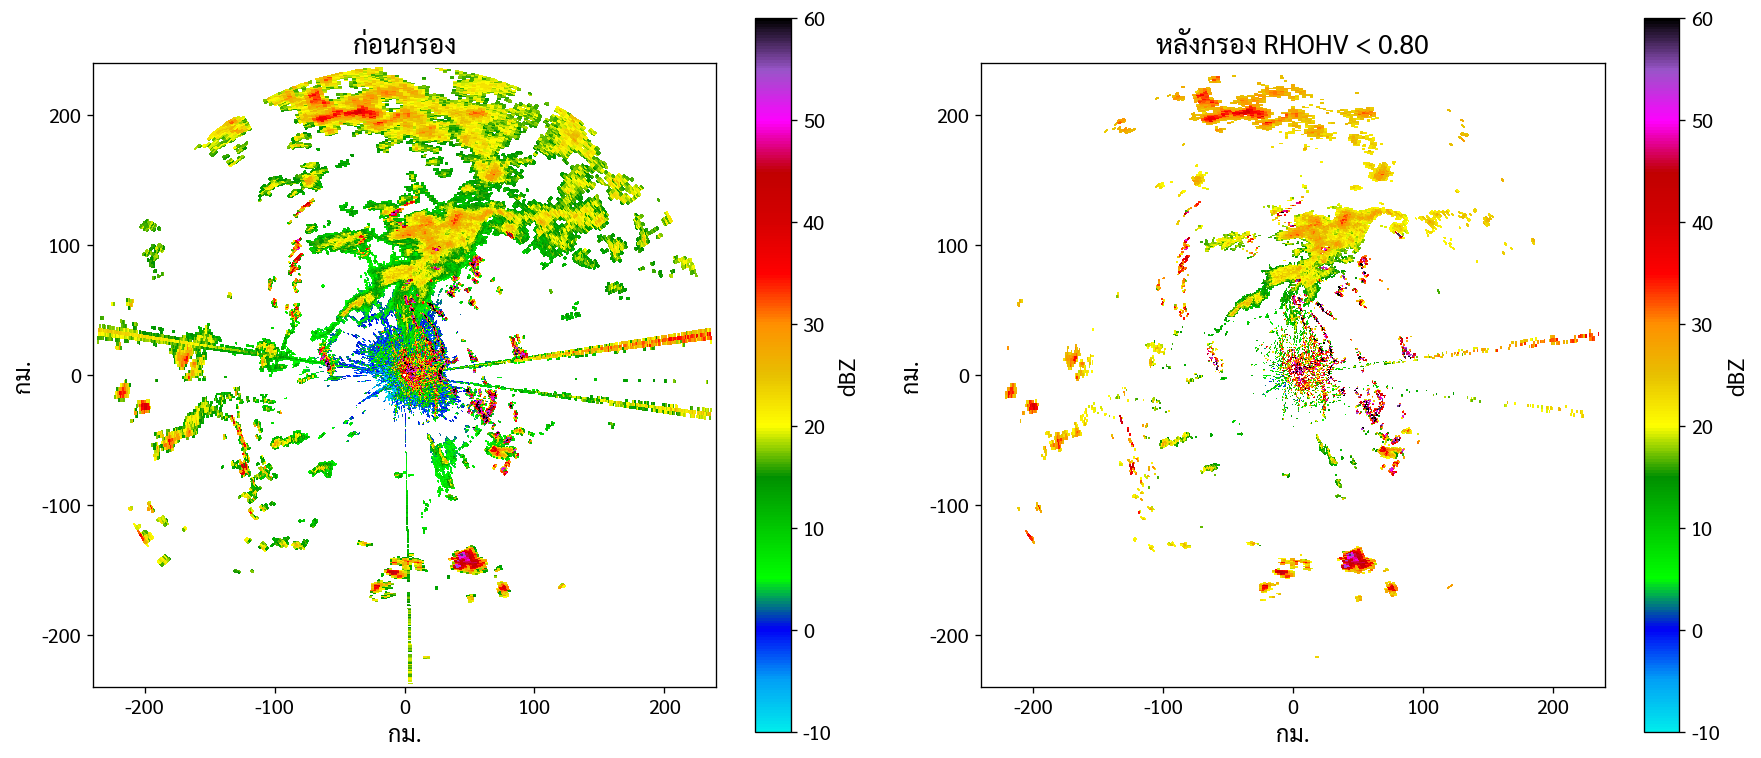

In [ ]:
gf_rho = pyart.filters.GateFilter(radar)
gf_rho.exclude_below('cross_correlation_ratio', 0.80)
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
ppi(axes[0], 'reflectivity', vmin=-10, vmax=60, label='dBZ', title='ก่อนกรอง')
ppi(axes[1], 'reflectivity', vmin=-10, vmax=60, gf=gf_rho, label='dBZ', title='หลังกรอง RHOHV < 0.80')
plt.tight_layout(); plt.show()

**การแปลผล:** speckle และ clutter รอบสถานีถูกตัด เหลือฝนที่สะอาดขึ้น


## A3 — ทัวร์เมธอดของ GateFilter

ดูผลของแต่ละเมธอดอย่างรวดเร็ว: ตัดสัญญาณอ่อน (`exclude_below` dBZ), ตัดค่านอกช่วง (`exclude_outside` ZDR), ตัดค่าไม่สมบูรณ์ (`exclude_invalid/masked`)


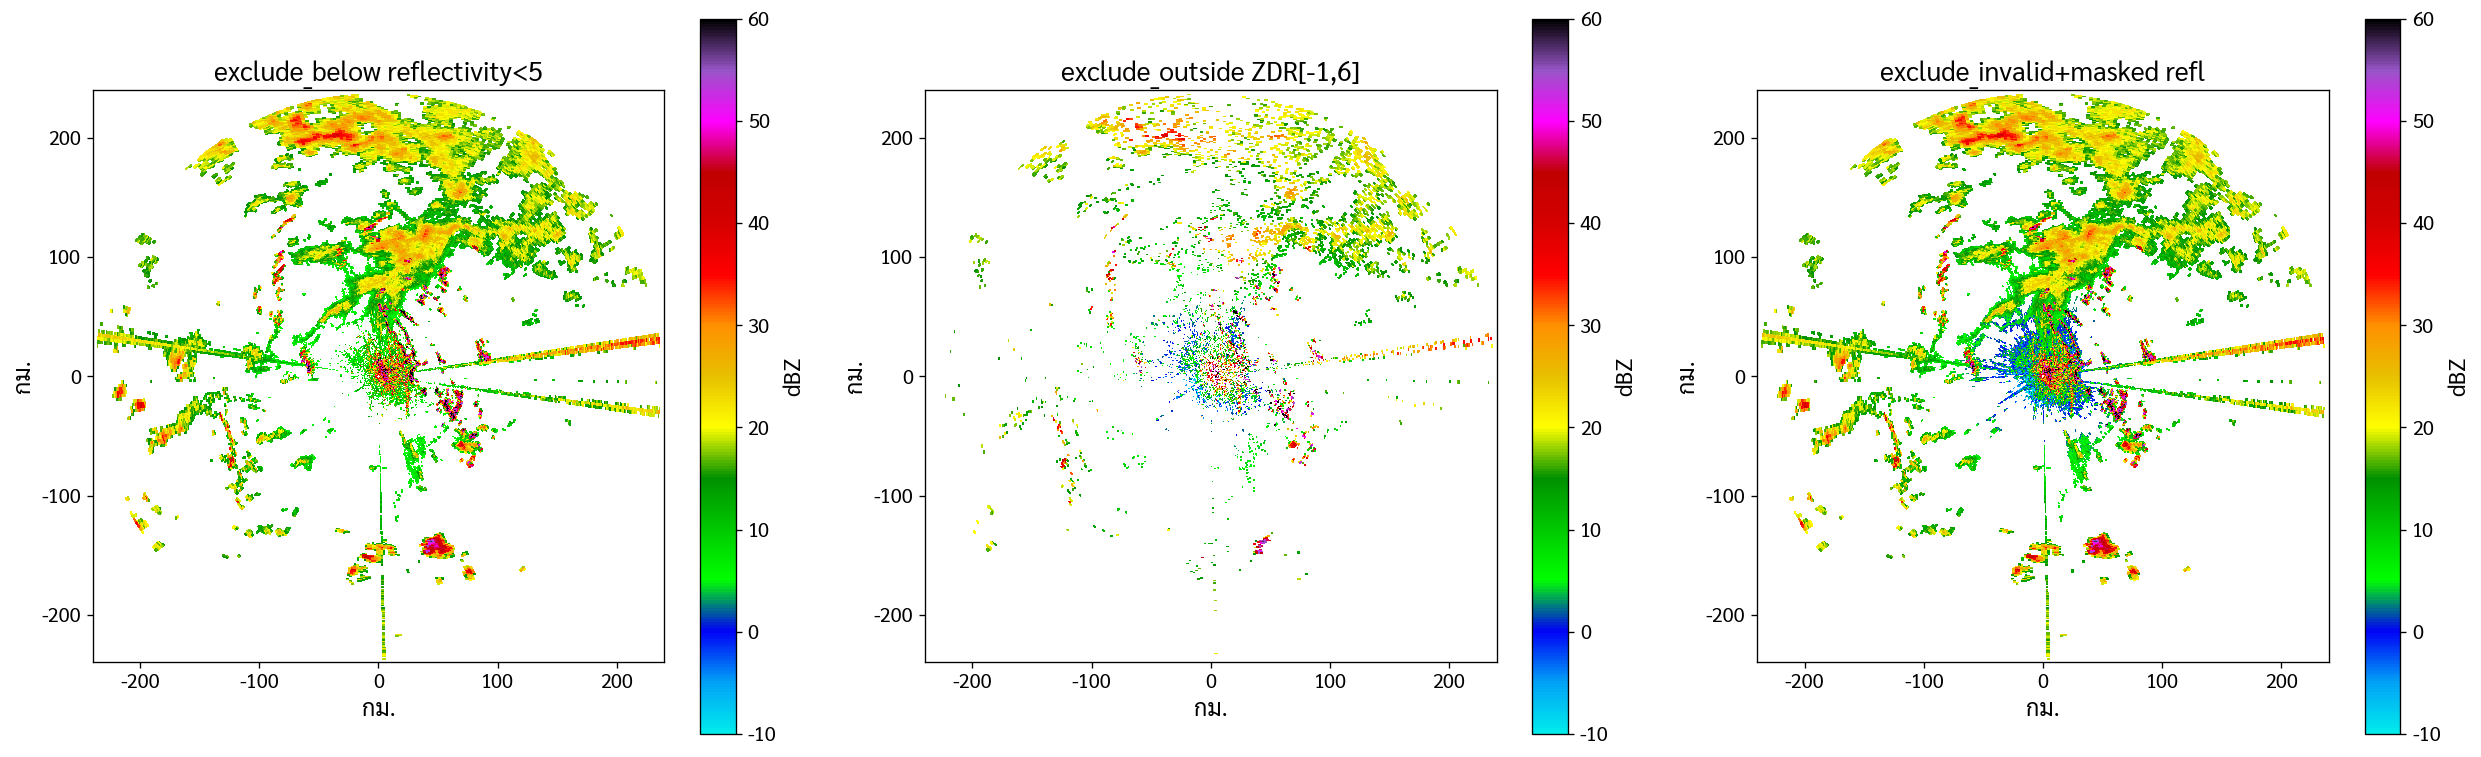

In [ ]:
cfg = [
    ("exclude_below reflectivity<5", lambda gf: gf.exclude_below('reflectivity', 5.0)),
    ("exclude_outside ZDR[-1,6]",    lambda gf: gf.exclude_outside('corrected_differential_reflectivity', -1.0, 6.0)),
    ("exclude_invalid+masked refl",  lambda gf: (gf.exclude_invalid('reflectivity'), gf.exclude_masked('reflectivity'))),
]
fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))
for ax, (name, fn) in zip(axes, cfg):
    gf = pyart.filters.GateFilter(radar); fn(gf)
    ppi(ax, 'reflectivity', vmin=-10, vmax=60, gf=gf, label='dBZ', title=name)
plt.tight_layout(); plt.show()

**การแปลผล:** แต่ละเมธอดจัดการปัญหาต่างกัน — จริงจังแล้วเรามัก **รวมหลายเมธอด** เข้าด้วยกัน (ตอนที่ 3)


---
# ตอนที่ 2 — SNR และการทดสอบ TOA

## A4 — SNR และ TOA คืออะไร?

**SNR (Signal-to-Noise Ratio)** = อัตราส่วนสัญญาณต่อสัญญาณรบกวน (dB) ค่าต่ำ = สัญญาณจม noise Py-ART ประมาณ SNR จาก reflectivity ด้วย `calculate_snr_from_reflectivity`

**TOA (Top Of Atmosphere)** = ระดับความสูง (เมตร) ที่ใช้อ้างอิงว่า "เหนือระดับนี้คือ noise" เพื่อประมาณ **noise floor** ตามระยะ

> ⚠️ **ค่า TOA มีผลมาก**: ถ้า TOA สูงเกินไป (เช่น 25,000 ม.) จะมี gate ที่อยู่สูงกว่านั้นน้อย → ประมาณ noise floor ได้ไม่ดี → SNR อาจ **ว่างเปล่า/เพี้ยน** เราจึงต้อง **ทดสอบ sensitivity** ก่อนเลือกใช้


## A5 — ทดสอบ Sensitivity ของ TOA ⭐

ลองหลายค่า TOA แล้วดูทั้ง **สัดส่วนข้อมูลที่ใช้ได้**, **ช่วงค่า SNR** และ **แผนที่** เพื่อเลือกค่าที่เหมาะ


In [ ]:
toa_list = [10000., 15000., 20000., 25000., 30000.]
snr_by_toa = {}
rows = []
for toa in toa_list:
    try:
        snr = pyart.retrieve.calculate_snr_from_reflectivity(radar, refl_field='reflectivity', toa=toa)
        d = snr['data']
        snr_by_toa[toa] = snr
        valid = ~np.ma.getmaskarray(d)
        rows.append({'TOA (m)': int(toa),
                     '% ข้อมูลใช้ได้': round(100*valid.mean(), 1),
                     'SNR เฉลี่ย (dB)': round(float(np.ma.mean(d)), 1) if valid.any() else np.nan,
                     'SNR ต่ำสุด': round(float(np.ma.min(d)), 1) if valid.any() else np.nan,
                     'SNR สูงสุด': round(float(np.ma.max(d)), 1) if valid.any() else np.nan})
    except Exception as e:
        rows.append({'TOA (m)': int(toa), '% ข้อมูลใช้ได้': 0, 'SNR เฉลี่ย (dB)': np.nan})
pd.DataFrame(rows)

,TOA (m),% ข้อมูลใช้ได้,SNR เฉลี่ย (dB),SNR ต่ำสุด,SNR สูงสุด
0,10000,24.5,10.2,-7.2,91.3
1,15000,24.5,11.5,-5.9,92.6
2,20000,0.0,NaN,NaN,NaN
3,25000,0.0,NaN,NaN,NaN
4,30000,0.0,NaN,NaN,NaN


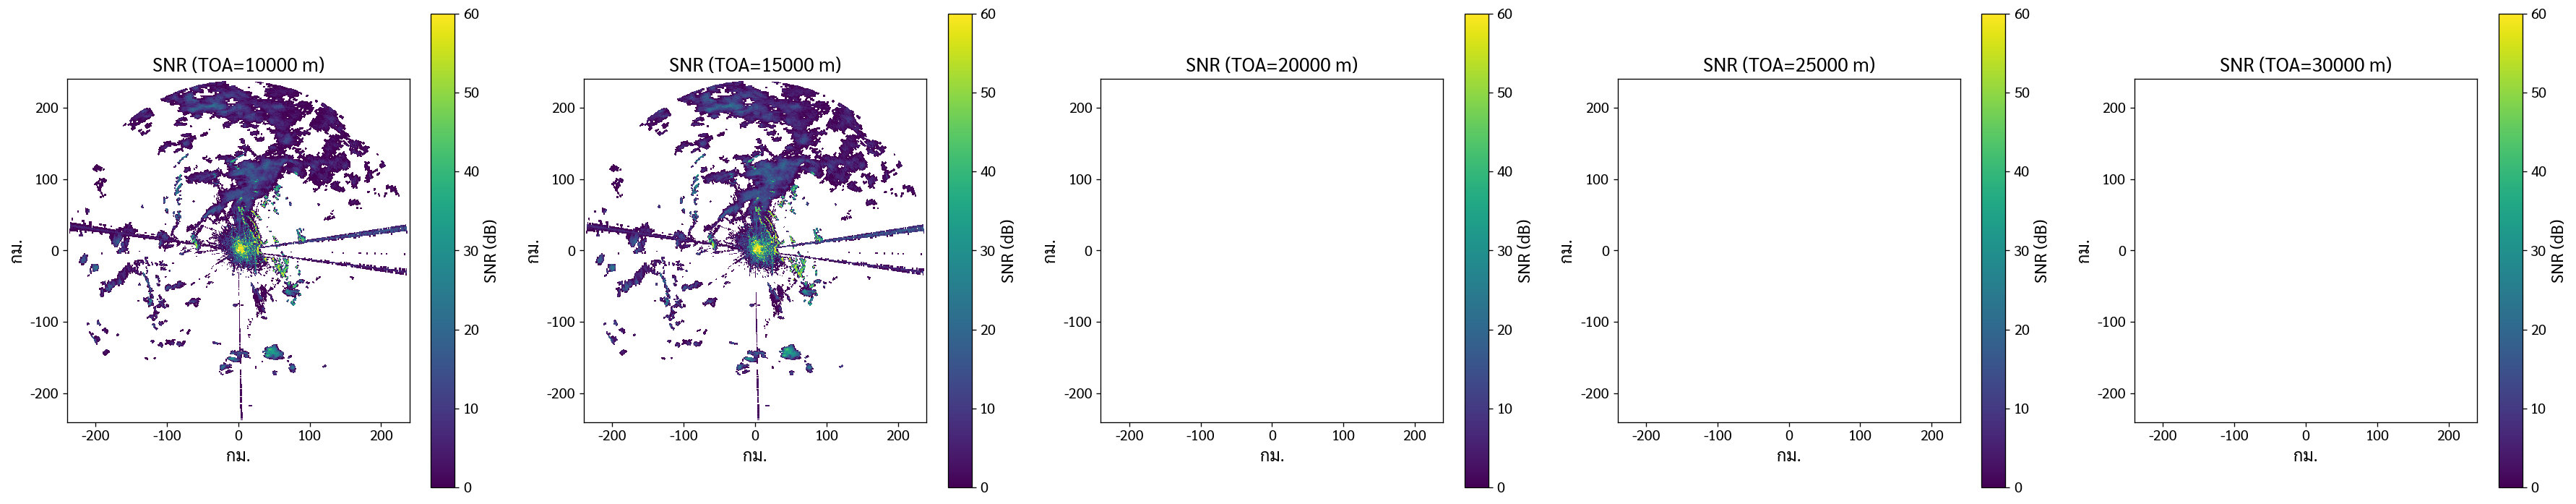

In [ ]:
# แผนที่ SNR ของแต่ละ TOA (สังเกตว่าค่าสูงเกินไปทำให้ภาพจาง/ว่าง)
avail = [t for t in toa_list if t in snr_by_toa]
fig, axes = plt.subplots(1, len(avail), figsize=(6*len(avail), 6))
axes = np.atleast_1d(axes)
for ax, toa in zip(axes, avail):
    radar.add_field('snr_tmp', snr_by_toa[toa], replace_existing=True)
    ppi(ax, 'snr_tmp', vmin=0, vmax=60, cmap='viridis', title=f'SNR (TOA={int(toa)} m)', label='SNR (dB)')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A5_toa_sensitivity.png'), dpi=200, bbox_inches='tight')
plt.show()

**การแปลผล:** TOA ต่ำ–กลาง (เช่น 10,000–15,000 ม.) ให้ SNR ที่มีข้อมูลครบและช่วงค่าสมเหตุสมผล ส่วน TOA สูงมาก (25,000–30,000 ม.) มัก **ว่าง/เพี้ยน** เพราะ gate เหนือระดับนั้นมีน้อย — นี่คือสาเหตุที่ภาพ SNR เคยออกมาว่างเปล่า


## A6 — เลือก TOA ที่เหมาะ แล้วเทียบ SNR กับ reflectivity


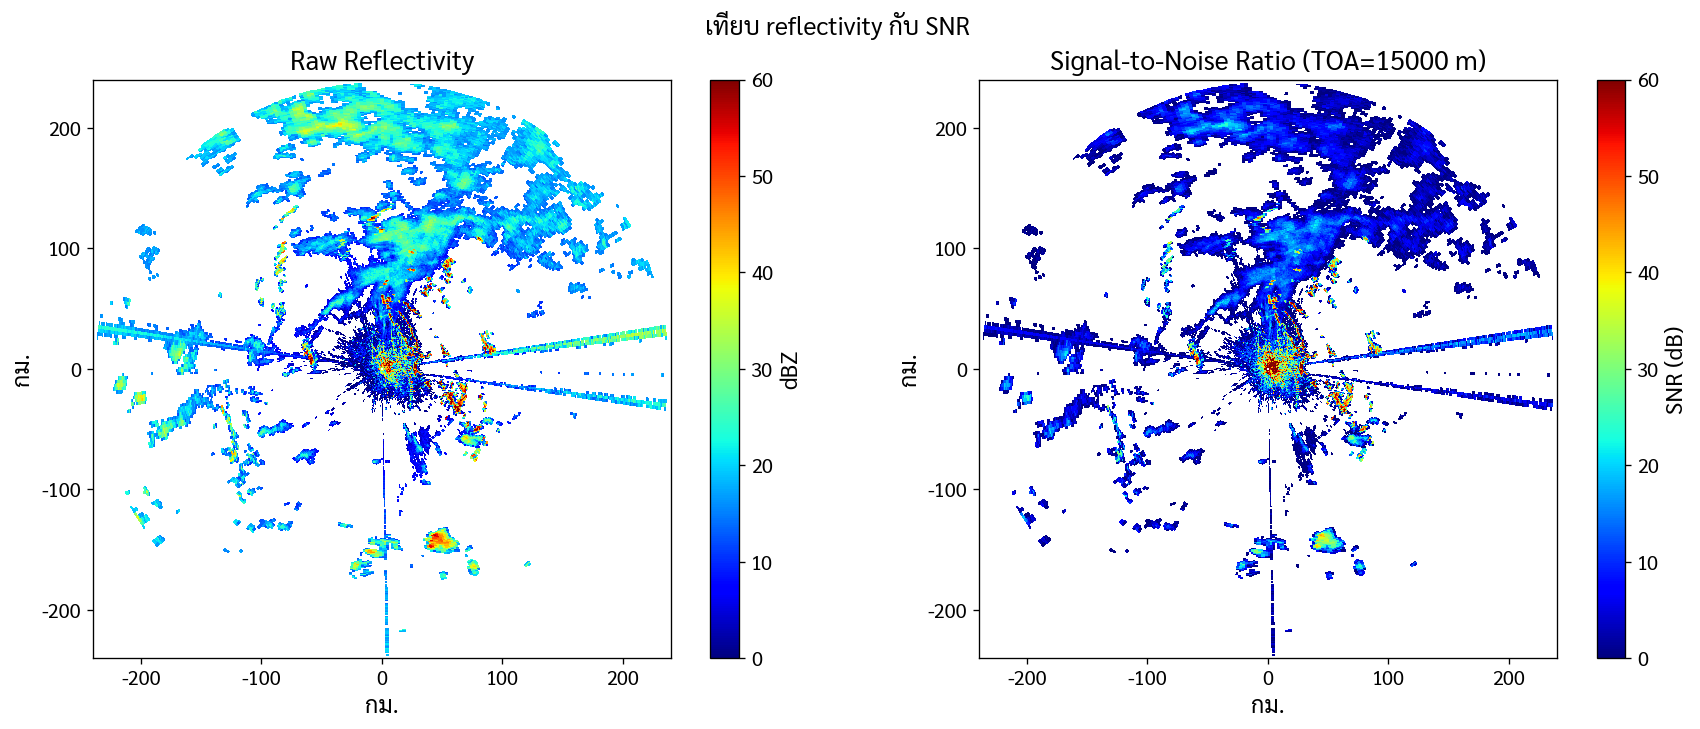

In [ ]:
TOA = 15000.0    # เลือกจากผลทดสอบ A5 (ปรับได้)
snr = pyart.retrieve.calculate_snr_from_reflectivity(radar, refl_field='reflectivity', toa=TOA)
radar.add_field('signal_to_noise_ratio', snr, replace_existing=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ppi(axes[0], 'reflectivity', vmin=0, vmax=60, cmap='jet', label='dBZ', title='Raw Reflectivity')
ppi(axes[1], 'signal_to_noise_ratio', vmin=0, vmax=60, cmap='jet', label='SNR (dB)',
    title=f'Signal-to-Noise Ratio (TOA={int(TOA)} m)')
plt.suptitle('เทียบ reflectivity กับ SNR', fontsize=15)
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A6_snr_vs_refl.png'), dpi=200, bbox_inches='tight')
plt.show()

**การแปลผล:** SNR สูงตรงบริเวณฝนจริง และต่ำในบริเวณสัญญาณรบกวน — ใช้เป็นเกณฑ์กรอง noise ได้


---
# ตอนที่ 3 — กรอง Noise/Clutter หลายเงื่อนไข

## A7 — `moment_and_texture_based_gate_filter` + SNR → `filtered_reflectivity`

ตัวกรองนี้ใช้ **texture (ความหยาบ) ของหลายโมเมนต์** ร่วมกับเงื่อนไข SNR เพื่อกำจัด noise/clutter อย่างมีประสิทธิภาพ แล้วสร้างฟิลด์ `filtered_reflectivity` (ตามแนวทาง notebook 04 ของหลักสูตร)


In [ ]:
SNR_MIN, SNR_MAX = 3.0, 60.0     # เกณฑ์ SNR (ปรับได้: ต้นฉบับใช้ 1 และ 70)

try:
    gtfilter = pyart.filters.moment_and_texture_based_gate_filter(radar, phi_field='differential_phase')
    used = 'moment_and_texture_based_gate_filter + SNR'
except Exception as e:
    print("ใช้ texture-based ไม่ได้ ใช้ RHOHV แทน:", repr(e))
    gtfilter = pyart.filters.GateFilter(radar)
    gtfilter.exclude_below('cross_correlation_ratio', 0.70)
    used = 'RHOHV + SNR (fallback)'

gtfilter.exclude_below('signal_to_noise_ratio', SNR_MIN)
gtfilter.exclude_above('signal_to_noise_ratio', SNR_MAX)

# สร้างฟิลด์ filtered_reflectivity โดย mask ตามตัวกรอง
radar.add_field_like('reflectivity', 'reflectivity_copy',
                     radar.fields['reflectivity']['data'].copy(), replace_existing=True)
nf = radar.fields['reflectivity_copy']
nf['data'] = np.ma.masked_where(gtfilter.gate_excluded, nf['data'])
radar.add_field('filtered_reflectivity', nf, replace_existing=True)
print("ตัวกรองที่ใช้:", used)
print("ฟิลด์ทั้งหมด:", list(radar.fields.keys()))

ตัวกรองที่ใช้: moment_and_texture_based_gate_filter + SNR
ฟิลด์ทั้งหมด: ['reflectivity', 'velocity', 'spectrum_width', 'corrected_reflectivity', 'corrected_differential_reflectivity', 'differential_phase', 'cross_correlation_ratio', 'snr_tmp', 'signal_to_noise_ratio', 'reflectivity_copy', 'filtered_reflectivity']


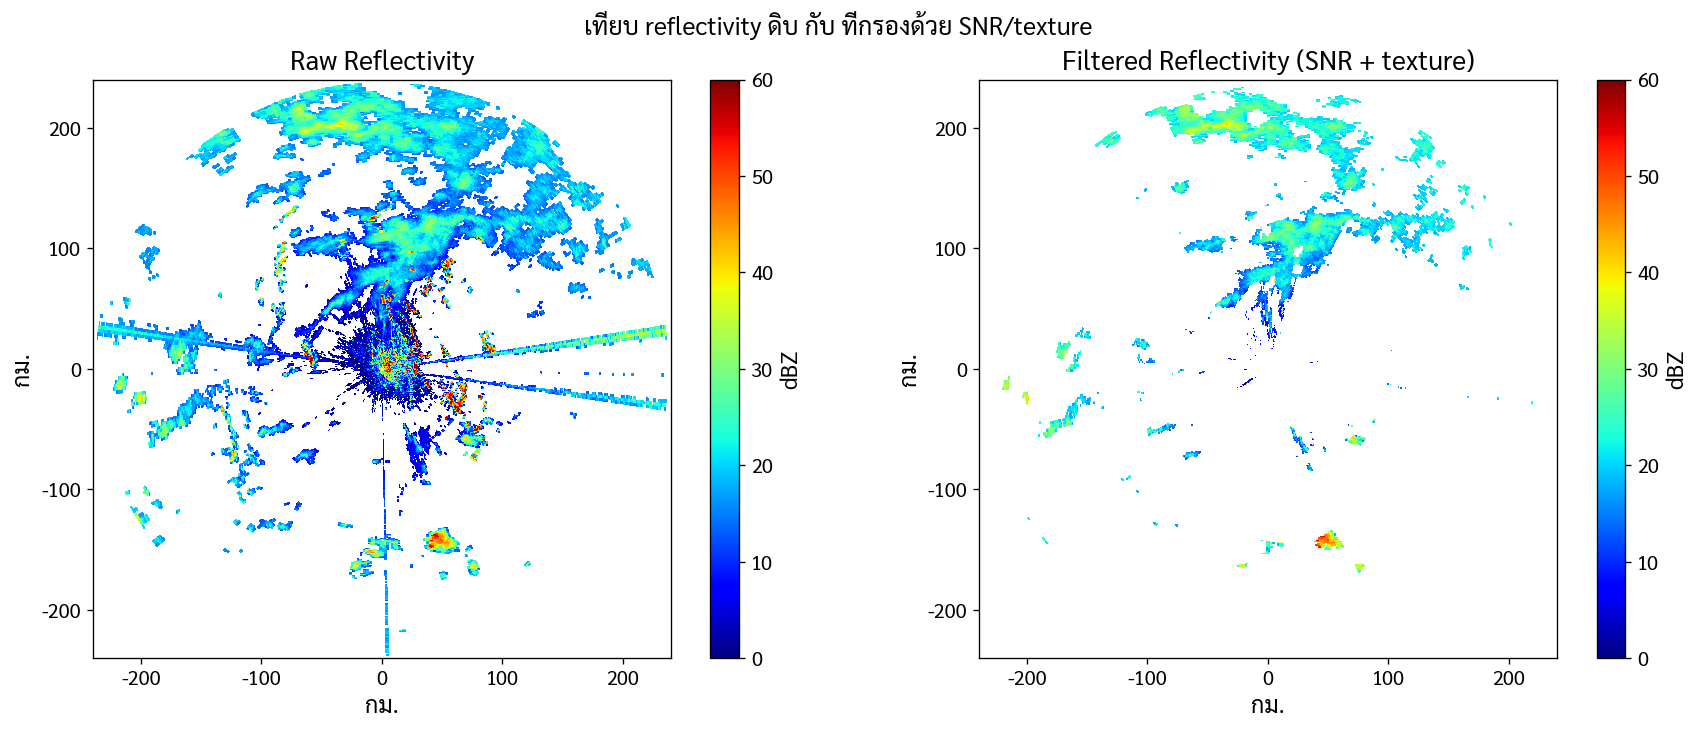

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ppi(axes[0], 'reflectivity', vmin=0, vmax=60, cmap='jet', label='dBZ', title='Raw Reflectivity')
ppi(axes[1], 'filtered_reflectivity', vmin=0, vmax=60, cmap='jet', label='dBZ',
    title='Filtered Reflectivity (SNR + texture)')
plt.suptitle('เทียบ reflectivity ดิบ กับ ที่กรองด้วย SNR/texture', fontsize=15)
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A7_filtered_reflectivity.png'), dpi=200, bbox_inches='tight')
plt.show()

**การแปลผล:** noise/clutter (รวมทั้ง flare สัญญาณเป็นเส้น) ถูกกำจัด เหลือโครงสร้างฝนที่สะอาด พร้อมนำไปปรับแก้ attenuation (บท 07), gridding และ QPE


## A8 — รวมหลายเงื่อนไข + ตาราง % + ค่าที่เก็บ vs ตัดออก


,เงื่อนไข,echo จริงที่ถูกตัด (%)
0,RHOHV < 0.80,61.4
1,SNR < 3,31.9
2,SNR > 60,2.3
3,ตัวกรองรวม (SNR+texture),69.4


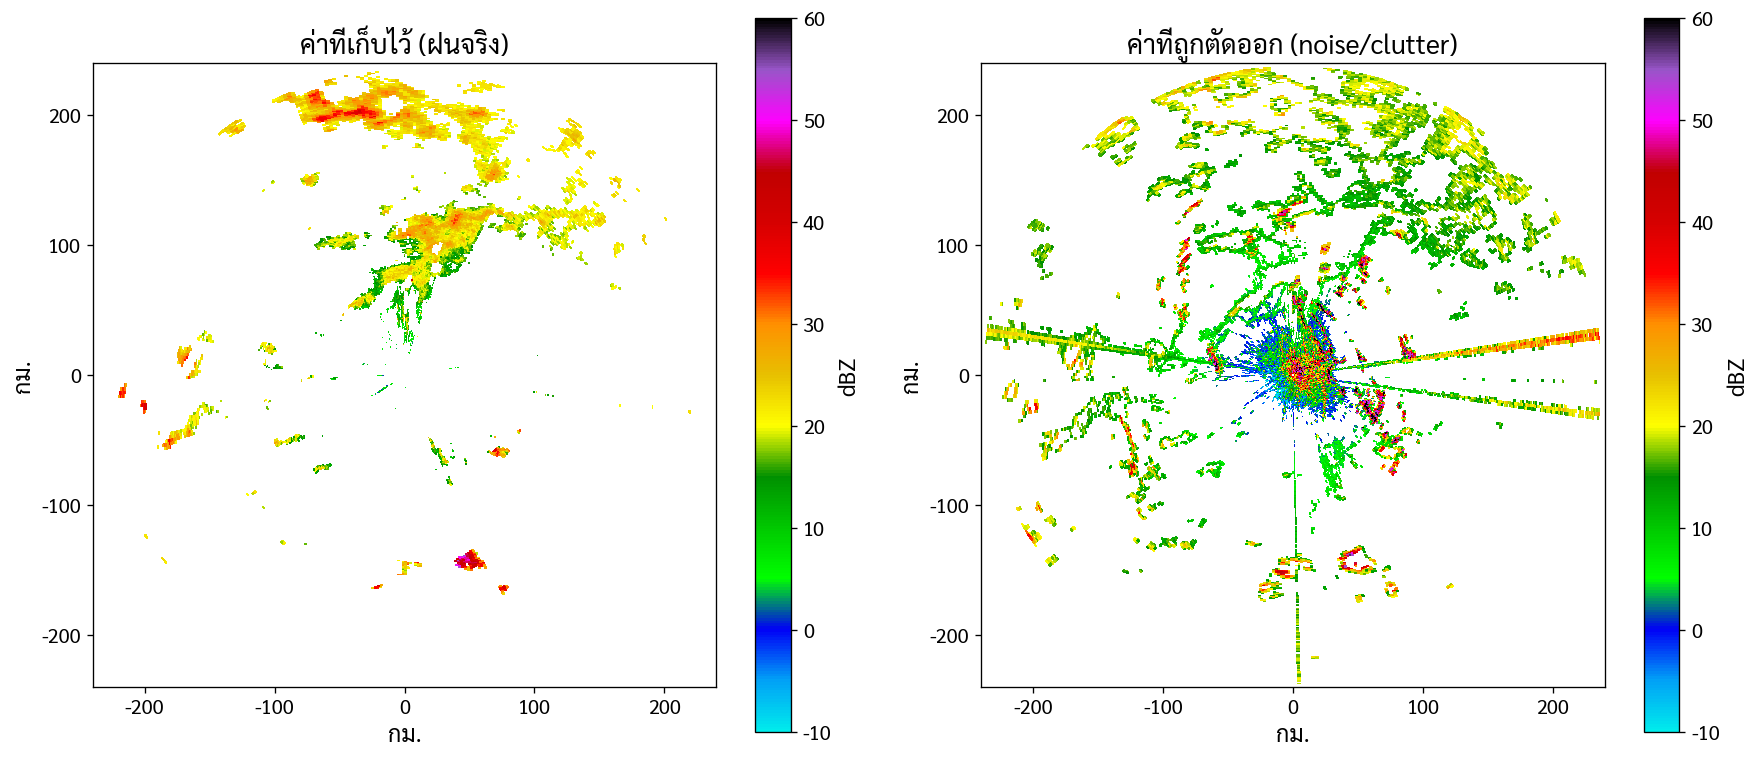

In [ ]:
refl = radar.fields['reflectivity']['data']
valid = ~np.ma.getmaskarray(refl); n_valid = int(valid.sum())
def pct(gf): return 100.0 * (gf.gate_excluded & valid).sum() / max(n_valid,1)

def one(fn):
    gf = pyart.filters.GateFilter(radar); fn(gf); return gf

rows = [
    ('RHOHV < 0.80',  pct(one(lambda gf: gf.exclude_below('cross_correlation_ratio', 0.80)))),
    ('SNR < %.0f' % SNR_MIN, pct(one(lambda gf: gf.exclude_below('signal_to_noise_ratio', SNR_MIN)))),
    ('SNR > %.0f' % SNR_MAX, pct(one(lambda gf: gf.exclude_above('signal_to_noise_ratio', SNR_MAX)))),
    ('ตัวกรองรวม (SNR+texture)', pct(gtfilter)),
]
display(pd.DataFrame(rows, columns=['เงื่อนไข','echo จริงที่ถูกตัด (%)']).round(1))

# ค่าที่เก็บ vs ตัดออก
excluded_only = np.ma.masked_where(~gtfilter.gate_excluded, refl)
kept_only     = np.ma.masked_where(gtfilter.gate_excluded, refl)
radar.add_field_like('reflectivity', 'refl_excluded', excluded_only, replace_existing=True)
radar.add_field_like('reflectivity', 'refl_kept', kept_only, replace_existing=True)
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
ppi(axes[0], 'refl_kept', vmin=-10, vmax=60, label='dBZ', title='ค่าที่เก็บไว้ (ฝนจริง)')
ppi(axes[1], 'refl_excluded', vmin=-10, vmax=60, label='dBZ', title='ค่าที่ถูกตัดออก (noise/clutter)')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A8_kept_vs_excluded.png'), dpi=200, bbox_inches='tight')
plt.show()

**การแปลผล:** ภาพ "ค่าที่ถูกตัดออก" ควรเป็น noise/clutter ไม่ใช่แกนฝนที่เป็นระเบียบ — ใช้ตรวจว่ากรองแรงไปหรือไม่


## A9 — กรอง Doppler velocity + trade-off เกณฑ์ RHOHV


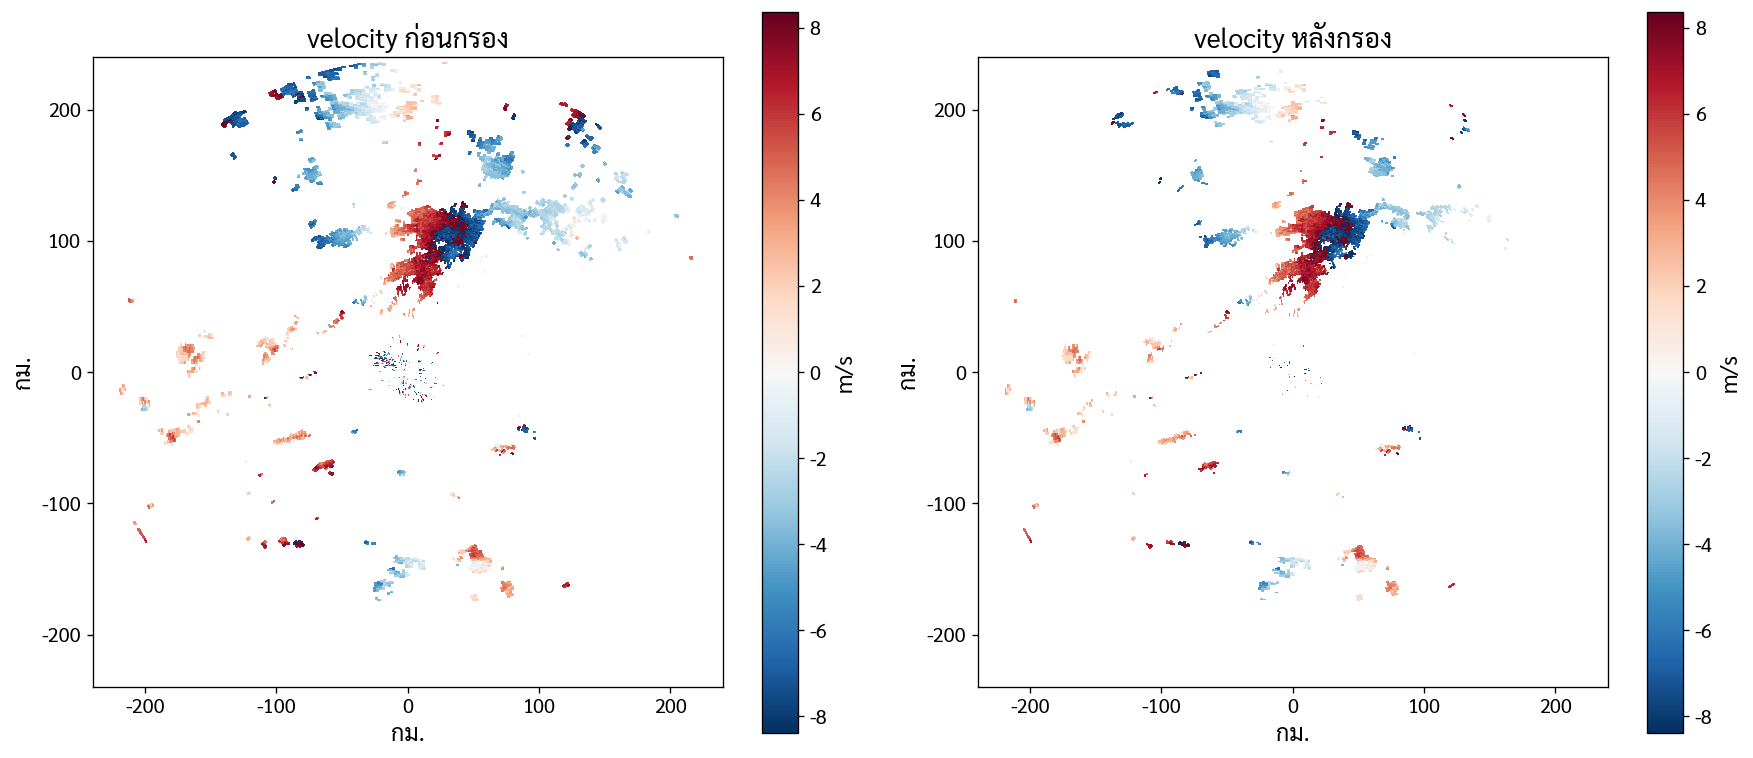

In [ ]:
gf_vel = pyart.filters.GateFilter(radar)
gf_vel.exclude_below('cross_correlation_ratio', 0.80)
gf_vel.exclude_masked('velocity')
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
ppi(axes[0], 'velocity', vmin=-nyq, vmax=nyq, cmap='RdBu_r', label='m/s', title='velocity ก่อนกรอง')
ppi(axes[1], 'velocity', vmin=-nyq, vmax=nyq, cmap='RdBu_r', gf=gf_vel, label='m/s', title='velocity หลังกรอง')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A9_velocity_masked.png'), dpi=200, bbox_inches='tight')
plt.show()

NameError: name 'pct' is not defined

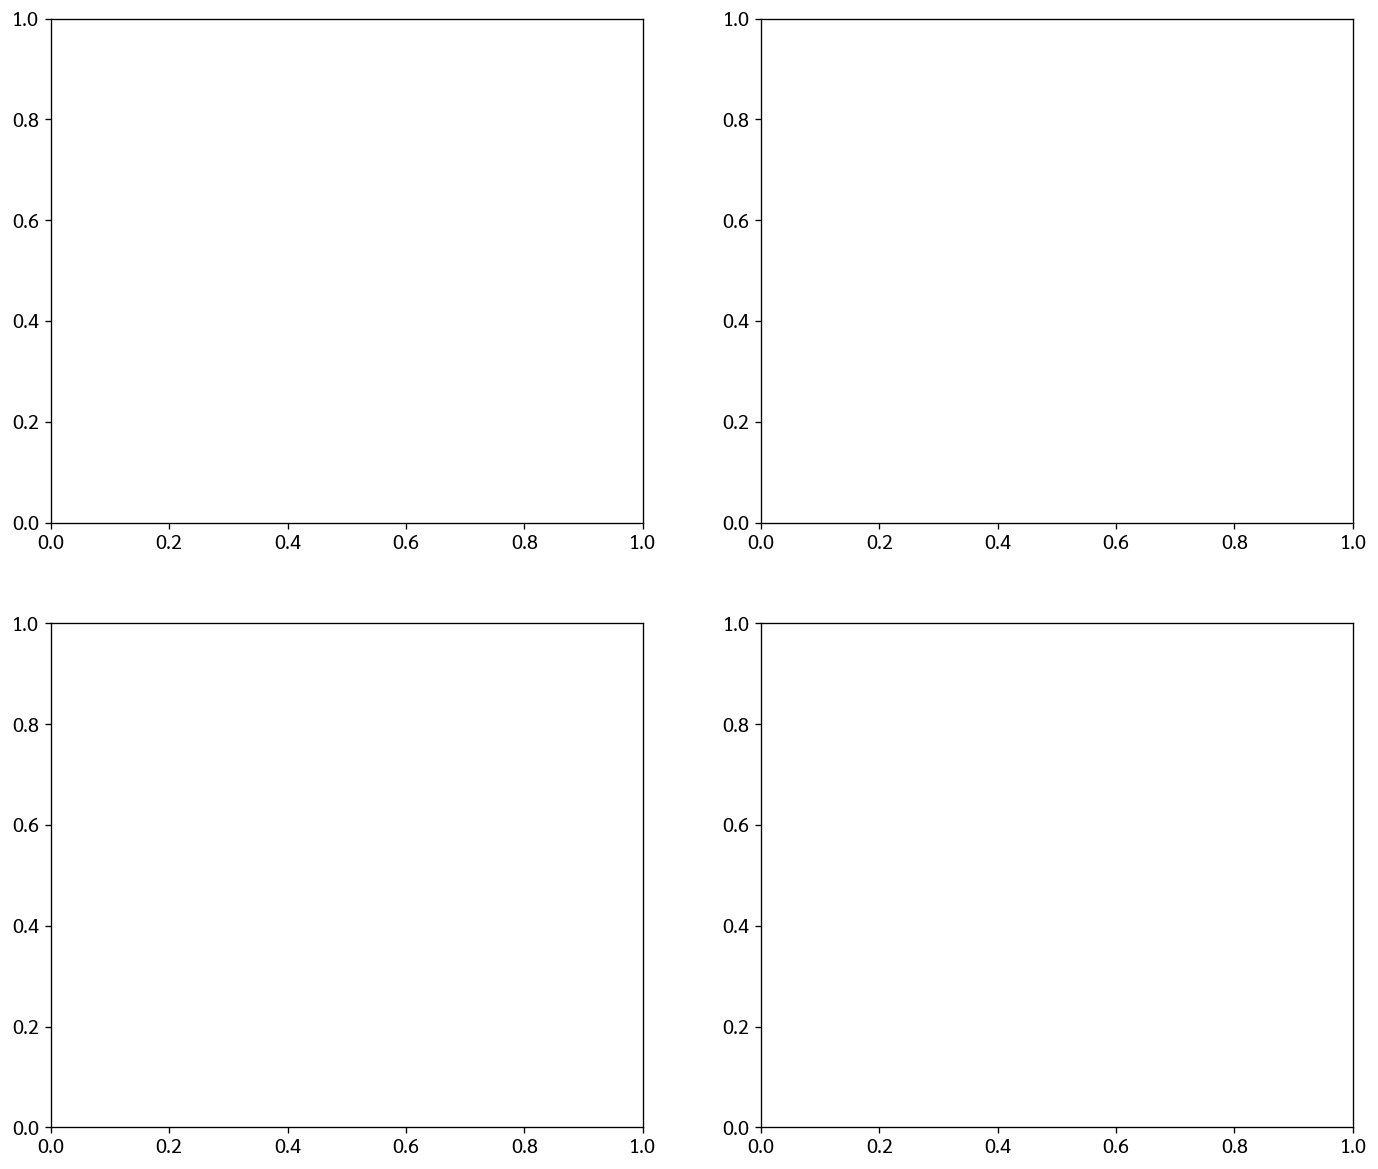

In [ ]:
# trade-off เกณฑ์ RHOHV
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, th in zip(axes.flat, [0.70, 0.80, 0.90, 0.95]):
    gf = pyart.filters.GateFilter(radar)
    gf.exclude_below('cross_correlation_ratio', th); gf.exclude_below('reflectivity', 0.0)
    ppi(ax, 'reflectivity', vmin=-10, vmax=60, gf=gf, label='dBZ', title=f'RHOHV ≥ {th:.2f} (ตัด {pct(gf):.1f}%)')
plt.tight_layout(); plt.show()

**การแปลผล:** เกณฑ์เข้มไป → สะอาดแต่ลบฝนจริง; หลวมไป → เหลือ clutter ต้องเลือกจุดสมดุล


---
# ตอนที่ 4 — ประยุกต์

## A10 — ผลของการกรองต่อ CAPPI / QPE

ใช้ `filtered_reflectivity` (ที่กรองแล้ว) ทำ CAPPI เทียบกับข้อมูลดิบ เพื่อเห็นผลปลายทางต่อผลิตภัณฑ์และการประเมินฝน


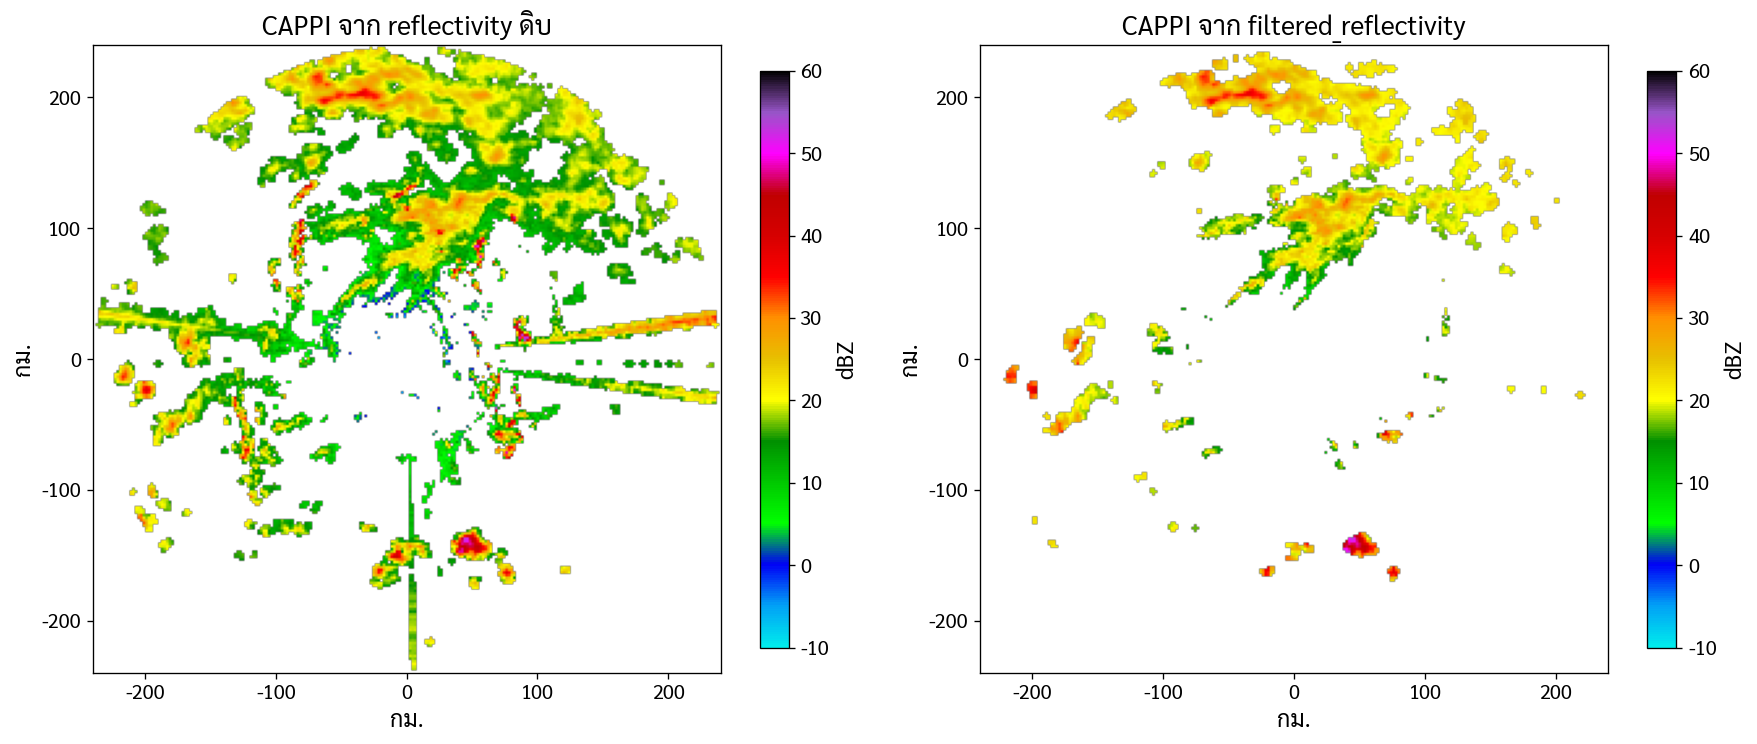

ฝนเฉลี่ยโดยประมาณ  ดิบ=0.200  กรองแล้ว=0.118 mm/hr
→ noise/clutter ที่ไม่กรองทำให้ประเมินฝนเพี้ยน โดยเฉพาะรอบสถานี


In [ ]:
def make_cappi(field, gf=None, n=241):
    g = pyart.map.grid_from_radars((radar,), gatefilters=((gf,) if gf else None),
        grid_shape=(1, n, n), grid_limits=((2000.,2000.), (-240000.,240000.), (-240000.,240000.)),
        fields=[field], weighting_function='Barnes2')
    return np.ma.filled(g.fields[field]['data'][0], np.nan)

cappi_raw = make_cappi('reflectivity')
cappi_qc  = make_cappi('filtered_reflectivity')

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, arr, t in zip(axes, [cappi_raw, cappi_qc], ['CAPPI จาก reflectivity ดิบ', 'CAPPI จาก filtered_reflectivity']):
    pm = ax.imshow(arr, origin='lower', extent=[-240,240,-240,240], cmap='NWSRef', vmin=-10, vmax=60)
    ax.set_title(t); ax.set_xlabel('กม.'); ax.set_ylabel('กม.'); ax.set_aspect('equal')
    plt.colorbar(pm, ax=ax, shrink=0.8, label='dBZ')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A10_cappi_qc_effect.png'), dpi=200, bbox_inches='tight')
plt.show()

def meanrain(cappi):
    R = (10.0**(cappi/10.0)/200.0)**(1/1.6)
    return np.nanmean(np.where(cappi>0, R, 0))
print(f"ฝนเฉลี่ยโดยประมาณ  ดิบ={meanrain(cappi_raw):.3f}  กรองแล้ว={meanrain(cappi_qc):.3f} mm/hr")
print("→ noise/clutter ที่ไม่กรองทำให้ประเมินฝนเพี้ยน โดยเฉพาะรอบสถานี")

## 📝 แบบฝึกหัด

1. จาก A5 เลือกค่า **TOA** ที่คุณคิดว่าเหมาะที่สุด พร้อมเหตุผลจากตาราง/แผนที่
2. ปรับ `SNR_MIN`/`SNR_MAX` (A7) หลายค่า แล้วดูภาพ `filtered_reflectivity` — เกณฑ์ใดกำจัด noise ได้ดีโดยไม่ลบฝนจริง
3. เทียบ `filtered_reflectivity` (SNR+texture) กับการกรองด้วย RHOHV อย่างเดียว — ต่างกันตรงไหน
4. (ต่อยอด) นำ `filtered_reflectivity` ไปใช้ต่อในบท 07 (ปรับแก้ attenuation) และบท 08 (QPE)


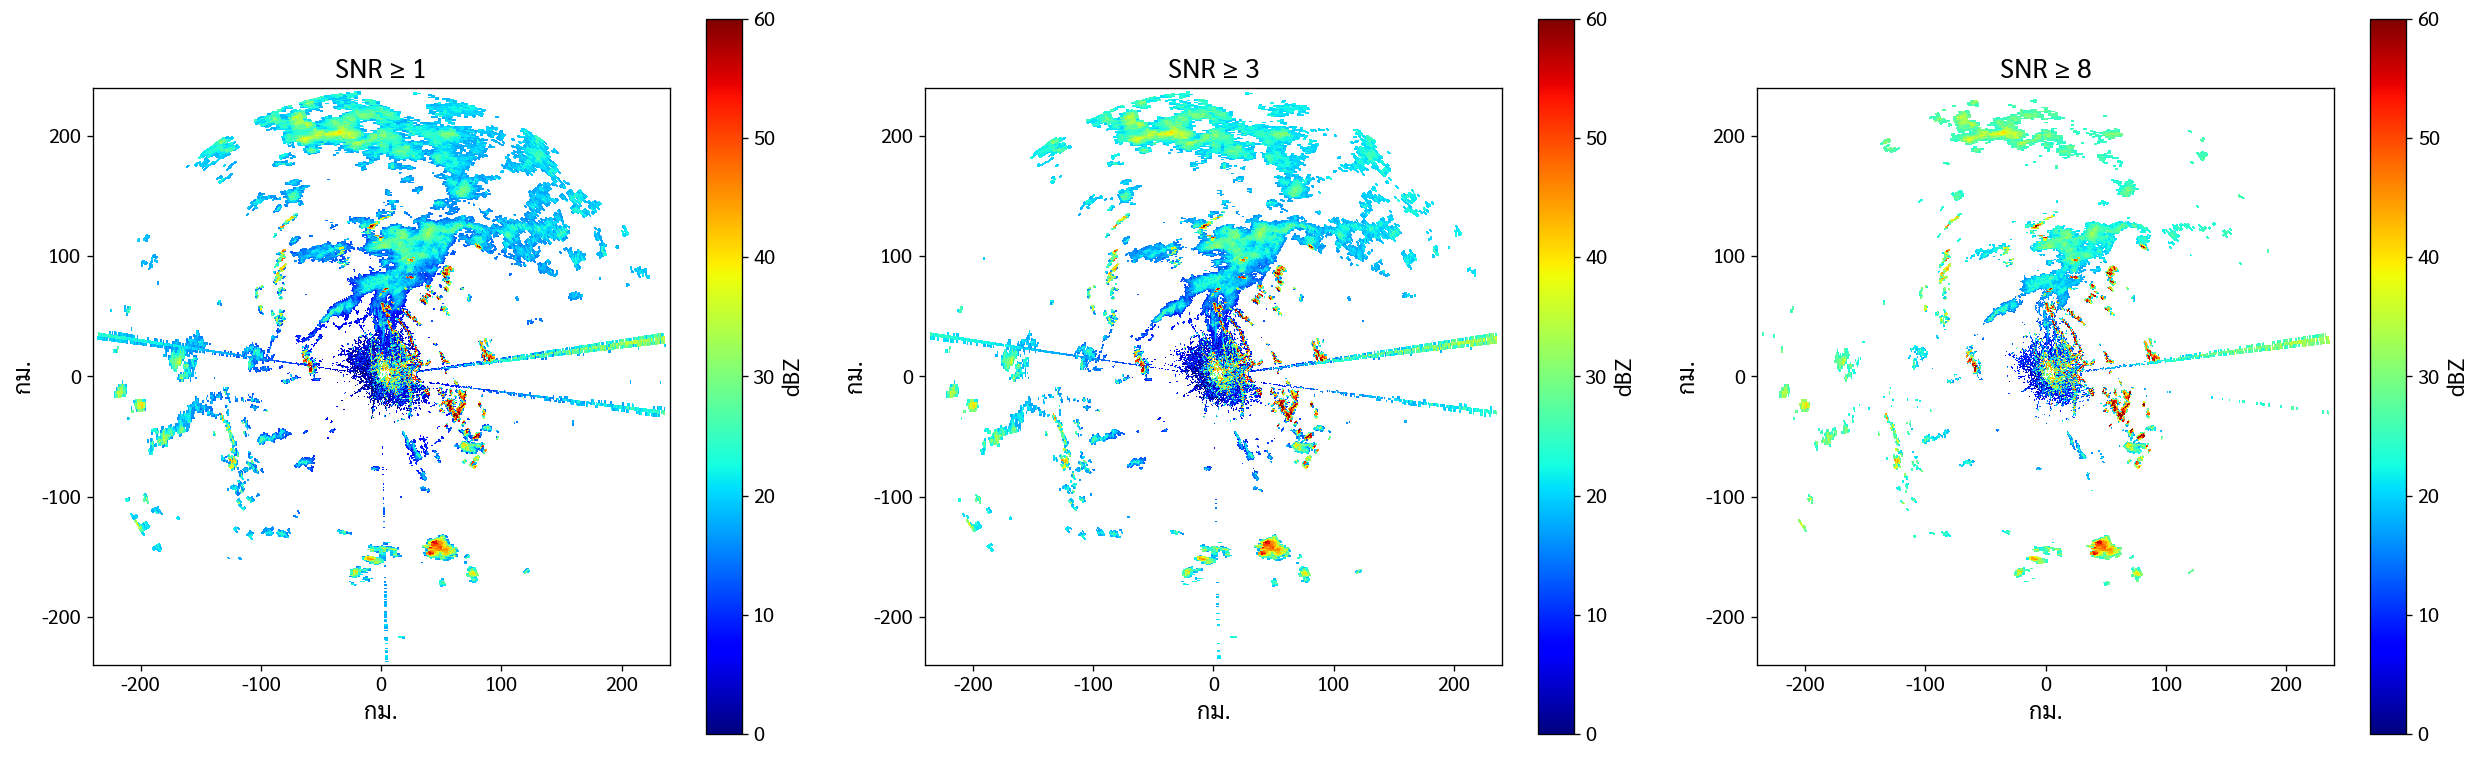

In [ ]:
# แบบฝึกหัดข้อ 2 (โครงเริ่มต้น): ทดสอบเกณฑ์ SNR_MIN หลายค่า
fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))
for ax, smin in zip(axes, [1.0, 3.0, 8.0]):
    gf = pyart.filters.GateFilter(radar)
    gf.exclude_below('signal_to_noise_ratio', smin)
    gf.exclude_above('signal_to_noise_ratio', SNR_MAX)
    ppi(ax, 'reflectivity', vmin=0, vmax=60, cmap='jet', gf=gf, label='dBZ', title=f'SNR ≥ {smin:.0f}')
plt.tight_layout(); plt.show()
# TODO (นิสิต): ทำข้อ 1, 3, 4 ต่อ

---
## 🎯 สรุป

- QC เป็นด่านแรกก่อนคำนวณทุกอย่าง — เข้าใจ `GateFilter` เงื่อนไขเดียวก่อน แล้วรวมหลายเงื่อนไข
- **SNR ต้องทดสอบร่วมกับ TOA** ก่อนใช้ (TOA สูงเกินไปทำให้ SNR ว่าง/เพี้ยน)
- การกรอง noise/clutter ที่ดีใช้ **SNR + texture (`moment_and_texture_based_gate_filter`)** แล้วสร้าง `filtered_reflectivity`
- ตรวจ "ค่าที่ถูกตัด" เสมอ และการกรองส่งผลต่อ CAPPI/QPE ปลายทางโดยตรง

**บทถัดไป — บทที่ 04:** Gridding — แปลง PPI เป็นกริดคาร์ทีเซียน, CAPPI, cone of silence และวิธี interpolation
